# **EDA of WhatsApp Integrity Data**

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [13]:
df =  pd.read_csv("data/data.csv")
df.head(3)

,wa_id,wa_sender_phone,wa_is_business,wa_spam_report_count,wa_about_text,wa_is_verified_biz,wa_body,wa_spoofed_sender,wa_label,phish_SFH,phish_popUpWidnow,phish_SSLfinal_State,phish_Request_URL,phish_URL_of_Anchor,phish_web_traffic,phish_URL_Length,phish_age_of_domain,phish_having_IP_Address,phish_Result
0,phish-0092,9.230257e+11,0.0,154.0,BISP Rewards Officer,0.0,Your account is locked. Verify now at http://s...,attacker@threat-mail.xyz,phishing,1,-1,0,-1,1,0,1,1,0,1
1,phish-0102,9.230243e+11,1.0,132.0,Urgent Account Support,0.0,"You won Rs.50,000! Claim here http://reward.xyz",attacker@threat-mail.xyz,phishing,1,0,1,0,-1,1,0,-1,0,-1
2,phish-0107,9.230214e+11,0.0,116.0,Urgent Account Support,0.0,"You won Rs.50,000! Claim here http://reward.xyz",attacker@threat-mail.xyz,phishing,-1,-1,-1,1,-1,0,-1,1,0,1


In [21]:
df.shape

(1353, 19)

- **Categorical**: wa_is_business, wa_is_verified_biz, wa_label

- **Numerical**: phish_SFH, phish_popUpWidnow, phish_SSLfinal_State, phish_Request_URL, phish_URL_of_Anchor, phish_web_traffic, phish_URL_Length, phish_age_of_domain, phish_having_IP_Address, phish_Result, wa_spam_report_count

- **Mixed**:wa_id, wa_sender_phone, wa_about_text, wa_body, wa_spoofed_sender

In [22]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1353 entries, 0 to 1352
Data columns (total 19 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   wa_id                    1000 non-null   str    
 1   wa_sender_phone          1000 non-null   float64
 2   wa_is_business           1000 non-null   float64
 3   wa_spam_report_count     1000 non-null   float64
 4   wa_about_text            1000 non-null   str    
 5   wa_is_verified_biz       1000 non-null   float64
 6   wa_body                  1000 non-null   str    
 7   wa_spoofed_sender        1000 non-null   str    
 8   wa_label                 1000 non-null   str    
 9   phish_SFH                1353 non-null   int64  
 10  phish_popUpWidnow        1353 non-null   int64  
 11  phish_SSLfinal_State     1353 non-null   int64  
 12  phish_Request_URL        1353 non-null   int64  
 13  phish_URL_of_Anchor      1353 non-null   int64  
 14  phish_web_traffic        1353 non-n

In [15]:
# calculate % of missing values in each column
df.isnull().sum()*100/len(df)


wa_id                      26.09017
wa_sender_phone            26.09017
wa_is_business             26.09017
wa_spam_report_count       26.09017
wa_about_text              26.09017
wa_is_verified_biz         26.09017
wa_body                    26.09017
wa_spoofed_sender          26.09017
wa_label                   26.09017
phish_SFH                   0.00000
phish_popUpWidnow           0.00000
phish_SSLfinal_State        0.00000
phish_Request_URL           0.00000
phish_URL_of_Anchor         0.00000
phish_web_traffic           0.00000
phish_URL_Length            0.00000
phish_age_of_domain         0.00000
phish_having_IP_Address     0.00000
phish_Result                0.00000
dtype: float64

In [23]:
df.duplicated().sum()

np.int64(73)

In [24]:
df.drop_duplicates(inplace=True)

- **Categorical**: wa_is_business, wa_is_verified_biz, wa_label

- **Numerical**: phish_SFH, phish_popUpWidnow, phish_SSLfinal_State, phish_Request_URL, phish_URL_of_Anchor, phish_web_traffic, phish_URL_Length, phish_age_of_domain, phish_having_IP_Address, phish_Result, wa_spam_report_count

- **Mixed**:wa_id, wa_sender_phone, wa_about_text, wa_body, wa_spoofed_sender

In [26]:
df.wa_label.value_counts()

wa_label
phishing    500
safe        500
Name: count, dtype: int64

In [27]:
df.wa_is_business.value_counts()

wa_is_business
0.0    513
1.0    487
Name: count, dtype: int64

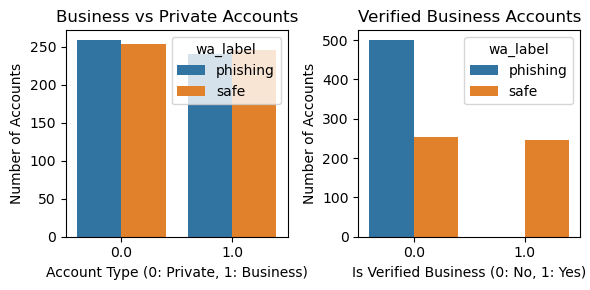

In [45]:
plt.figure(figsize=(6, 3))
plt.subplot(1, 2, 1)
sns.countplot(data=df, x='wa_is_business', hue='wa_label')

plt.title('Business vs Private Accounts')
plt.xlabel('Account Type (0: Private, 1: Business)')
plt.ylabel('Number of Accounts')

plt.subplot(1, 2, 2)
sns.countplot(data=df, x='wa_is_verified_biz', hue='wa_label')
plt.title('Verified Business Accounts')
plt.xlabel('Is Verified Business (0: No, 1: Yes)')
plt.ylabel('Number of Accounts')
plt.tight_layout()
plt.show()

- Both Business and private accounts are equally involved in cyber threats.
- All verified Accounts are safe

